In [2]:
import sys
from pathlib import Path

PASTA_ATUAL = Path.cwd().resolve()
if (PASTA_ATUAL / 'src').exists():
    RAIZ_PROJETO = PASTA_ATUAL
elif (PASTA_ATUAL.parent / 'src').exists():
    RAIZ_PROJETO = PASTA_ATUAL.parent
else:
    RAIZ_PROJETO = Path('..').resolve()

sys.path.insert(0, str(RAIZ_PROJETO))

from src.data_structures.linked_list import Linked_List_Compra, Linked_List_Venda
from src.data_structures.node import Node
from src.models.ordem import Ordem
from src.data_structures.queue import Queue
from src.data_structures.stack import Stack
from data.order_generator import gerar_multiplos_csv

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import re


## 1. Configuração: localizando os arquivos CSV

In [3]:
volumes = [10, 100, 1000, 10000]
PASTA_DADOS = RAIZ_PROJETO / "data"

arquivos_csv = {
    volume: PASTA_DADOS / f"orders_{volume}.csv"
    for volume in volumes
}

faltando = [
    caminho
    for caminho in arquivos_csv.values()
    if not caminho.exists()
]

if faltando:
    print("Alguns arquivos CSV não foram encontrados. Gerando novamente...")
    gerar_multiplos_csv(PASTA_DADOS, volumes)
else:
    print("Todos os arquivos CSV já existem.")

for volume, caminho in arquivos_csv.items():
    print(f"{volume} ordens -> {caminho} | existe? {caminho.exists()}")

Todos os arquivos CSV já existem.
10 ordens -> /home/andrecarvalho/Área de trabalho/ed/Trabalho-ED/data/orders_10.csv | existe? True
100 ordens -> /home/andrecarvalho/Área de trabalho/ed/Trabalho-ED/data/orders_100.csv | existe? True
1000 ordens -> /home/andrecarvalho/Área de trabalho/ed/Trabalho-ED/data/orders_1000.csv | existe? True
10000 ordens -> /home/andrecarvalho/Área de trabalho/ed/Trabalho-ED/data/orders_10000.csv | existe? True


### 1.1 Exploração inicial (opcional, apenas para conferência)

Usa só o primeiro arquivo encontrado, igual à exploração feita na versão original — não entra nas medições de tempo.

In [6]:
df_exemplo = pd.read_csv(arquivos_csv[volumes[0]])

df_exemplo['ID'] = df_exemplo['ID'].convert_dtypes(convert_floating=True)
df_exemplo['Quantity'] = df_exemplo['Quantity'].convert_dtypes(convert_floating=True)

print(f'Exemplo baseado em: {arquivos_csv[volumes[0]].name}')
display(df_exemplo.head())

df_compras_exemplo = df_exemplo[df_exemplo['Type'] == 'C']
df_vendas_exemplo = df_exemplo[df_exemplo['Type'] == 'V']

print('Quantidade de compras:', df_compras_exemplo.shape[0])
print('Quantidade de vendas:', df_vendas_exemplo.shape[0])

Exemplo baseado em: orders_10.csv


,ID,Type,Price,Quantity,Timestamp
0,1,V,80.75,910,2026-06-25 15:21:32
1,2,C,55.53,490,2026-06-25 15:21:36
2,3,V,66.09,280,2026-06-25 15:21:38
3,4,V,96.59,300,2026-06-25 15:21:42
4,5,V,11.83,180,2026-06-25 15:21:43


Quantidade de compras: 3
Quantidade de vendas: 7


In [7]:
def criar_ordem_da_linha(linha):
    """Cria uma Ordem a partir de uma linha do CSV gerado pelo order_generator.py."""
    return Ordem(
        id_ordem=int(linha['ID']),
        tipo=str(linha['Type']),
        preco=float(linha['Price']),
        quantidade=int(linha['Quantity']),
        timestamp=linha.get('Timestamp', None)
    )


def benchmark_csv(caminho_csv):
    """Executa as medições de tempo para um único arquivo CSV de ordens."""
    resultados = {'arquivo': str(caminho_csv)}

    df = pd.read_csv(caminho_csv)

    # Garante tipos compatíveis com as classes do projeto.
    df['ID'] = df['ID'].astype(int)
    df['Type'] = df['Type'].astype(str)
    df['Price'] = df['Price'].astype(float)
    df['Quantity'] = df['Quantity'].astype(int)

    df_compras = df[df['Type'] == 'C']
    df_vendas = df[df['Type'] == 'V']

    resultados['num_ordens'] = len(df)
    resultados['num_compras'] = len(df_compras)
    resultados['num_vendas'] = len(df_vendas)

    # Inserção linked list vendas
    lista_venda = Linked_List_Venda()
    inicio = time.time()
    for _, linha in df_vendas.iterrows():
        ordem = criar_ordem_da_linha(linha)
        no = Node(ordem)
        lista_venda.adicionar_no(no)
    resultados['tempo_lista_venda_insercao'] = time.time() - inicio

    # Inserção linked list compras
    lista_compra = Linked_List_Compra()
    inicio = time.time()
    for _, linha in df_compras.iterrows():
        ordem = criar_ordem_da_linha(linha)
        no = Node(ordem)
        lista_compra.adicionar_no(no)
    resultados['tempo_lista_compra_insercao'] = time.time() - inicio

    # Inserção de uma ordem no meio da lista de compras
    if not df_compras.empty:
        preco_medio_compra = (df_compras['Price'].min() + df_compras['Price'].max()) / 2
        ordem_meio_compra = Ordem(
            id_ordem=int(df['ID'].max()) + 1,
            tipo='C',
            preco=float(preco_medio_compra),
            quantidade=20
        )
        acao_meio = Node(ordem_meio_compra)
        inicio = time.time()
        lista_compra.adicionar_no(acao_meio)
        resultados['tempo_lista_compra_insercao_meio'] = time.time() - inicio
    else:
        resultados['tempo_lista_compra_insercao_meio'] = 0

    # Inserção de uma ordem no meio da lista de vendas
    if not df_vendas.empty:
        preco_medio_venda = (df_vendas['Price'].min() + df_vendas['Price'].max()) / 2
        ordem_meio_venda = Ordem(
            id_ordem=int(df['ID'].max()) + 2,
            tipo='V',
            preco=float(preco_medio_venda),
            quantidade=30
        )
        acao_meio_venda = Node(ordem_meio_venda)
        inicio = time.time()
        lista_venda.adicionar_no(acao_meio_venda)
        resultados['tempo_lista_venda_insercao_meio'] = time.time() - inicio
    else:
        resultados['tempo_lista_venda_insercao_meio'] = 0

    # Stack: empilhar e desempilhar ordens de compra
    pilha_compra = Stack()
    inicio = time.time()
    for _, linha in df_compras.iterrows():
        ordem = criar_ordem_da_linha(linha)
        pilha_compra.empilhar(ordem)
    resultados['tempo_pilha_empilhar'] = time.time() - inicio

    inicio = time.time()
    pilha_compra.desempilhar()
    resultados['tempo_pilha_desempilhar'] = time.time() - inicio

    # Queue: enfileirar e desenfileirar ordens de compra
    queue_compra = Queue()
    inicio = time.time()
    for _, linha in df_compras.iterrows():
        ordem = criar_ordem_da_linha(linha)
        queue_compra.enfileirar(ordem)
    resultados['tempo_queue_enqueue'] = time.time() - inicio

    inicio = time.time()
    queue_compra.desenfileirar()
    resultados['tempo_queue_dequeue'] = time.time() - inicio

    return resultados

## 3. Executando o benchmark para todos os arquivos

In [9]:
resultados_totais = []

for volume in volumes:
    arquivo = arquivos_csv[volume]
    print(f'Processando {arquivo.name}...')

    resultado = benchmark_csv(arquivo)
    resultado['Volume'] = volume

    resultados_totais.append(resultado)

df_resultados = pd.DataFrame(resultados_totais)
df_resultados

Processando orders_10.csv...
Processando orders_100.csv...
Processando orders_1000.csv...
Processando orders_10000.csv...


,arquivo,num_ordens,num_compras,num_vendas,tempo_lista_venda_insercao,tempo_lista_compra_insercao,tempo_lista_compra_insercao_meio,tempo_lista_venda_insercao_meio,tempo_pilha_empilhar,tempo_pilha_desempilhar,tempo_queue_enqueue,tempo_queue_dequeue,Volume
0,/home/andrecarvalho/Área de trabalho/ed/Trabal...,10,3,7,0.000343,0.000144,0.000002,0.000001,0.000158,0.000002,0.000124,0.000001,10
1,/home/andrecarvalho/Área de trabalho/ed/Trabal...,100,54,46,0.001032,0.001134,0.000002,0.000002,0.001116,0.000002,0.001111,0.000002,100
2,/home/andrecarvalho/Área de trabalho/ed/Trabal...,1000,507,493,0.009324,0.009737,0.000015,0.000024,0.008022,0.000001,0.007944,0.000002,1000
3,/home/andrecarvalho/Área de trabalho/ed/Trabal...,10000,4957,5043,0.318655,0.291216,0.000120,0.000335,0.074013,0.000001,0.112788,0.000002,10000


## 4. Estatísticas resumidas (média, desvio padrão, mín. e máx. entre os arquivos)

In [10]:
colunas_tempo = [c for c in df_resultados.columns if c.startswith('tempo_')]

resumo_estatistico = df_resultados[colunas_tempo].agg(['mean', 'std', 'min', 'max']).T
resumo_estatistico.columns = ['média (s)', 'desvio padrão (s)', 'mínimo (s)', 'máximo (s)']
resumo_estatistico

,média (s),desvio padrão (s),mínimo (s),máximo (s)
tempo_lista_venda_insercao,0.082338,1.575971e-01,0.000343,0.318655
tempo_lista_compra_insercao,0.075558,1.438367e-01,0.000144,0.291216
tempo_lista_compra_insercao_meio,0.000035,5.689448e-05,0.000002,0.000120
tempo_lista_venda_insercao_meio,0.000091,1.633375e-04,0.000001,0.000335
tempo_pilha_empilhar,0.020827,3.562985e-02,0.000158,0.074013
tempo_pilha_desempilhar,0.000002,4.129531e-07,0.000001,0.000002
tempo_queue_enqueue,0.030492,5.497417e-02,0.000124,0.112788
tempo_queue_dequeue,0.000002,1.946680e-07,0.000001,0.000002


## 5. Gráficos comparativos

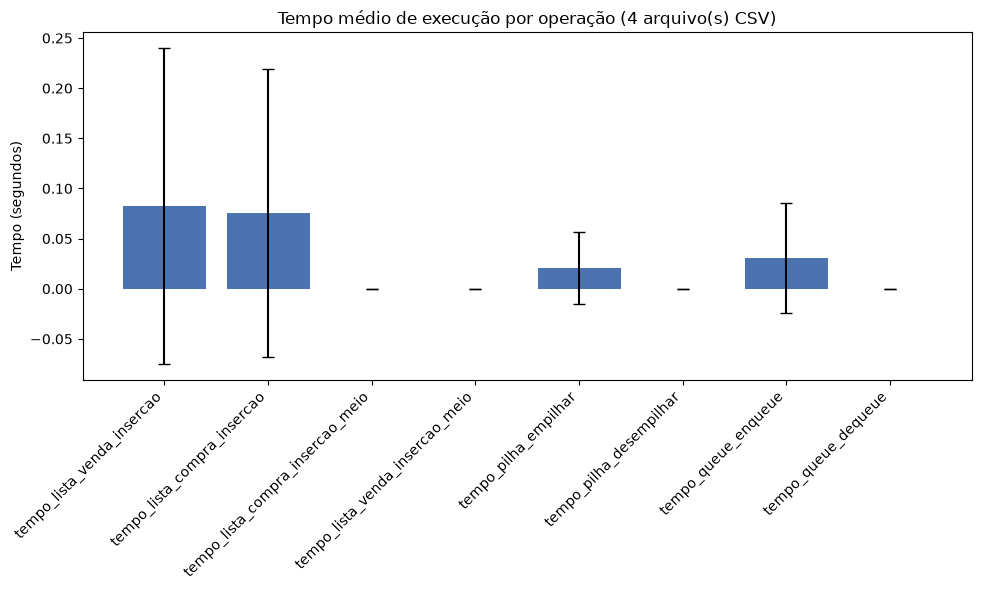

In [11]:
medias = df_resultados[colunas_tempo].mean()
desvios = df_resultados[colunas_tempo].std()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(medias.index, medias.values, yerr=desvios.values, capsize=4, color='#4C72B0')
ax.set_ylabel('Tempo (segundos)')
ax.set_title(f'Tempo médio de execução por operação ({len(arquivos_csv)} arquivo(s) CSV)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

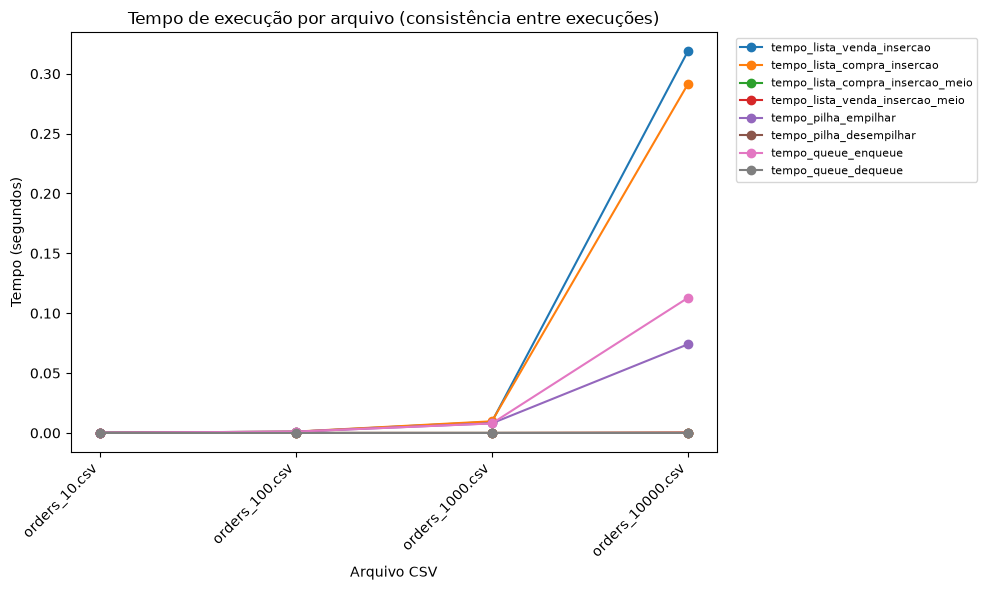

In [12]:
nomes_arquivos = [Path(a).name for a in df_resultados['arquivo']]

fig, ax = plt.subplots(figsize=(10, 6))
for coluna in colunas_tempo:
    ax.plot(nomes_arquivos, df_resultados[coluna], marker='o', label=coluna)

ax.set_ylabel('Tempo (segundos)')
ax.set_xlabel('Arquivo CSV')
ax.set_title('Tempo de execução por arquivo (consistência entre execuções)')
plt.xticks(rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
#df_resultados.to_csv('resultados_benchmark.csv', index=False)
#print("Resultados salvos em 'resultados_benchmark.csv'")

Resultados salvos em 'resultados_benchmark.csv'
